# 04 - Current Regime and Implied Portfolio

**Purpose:** identify the current macro regime in each region, using only data published by today, and show the portfolio the strategy would hold this month.

**Inputs:** `data/regimes.csv`, `data/signal_inputs.csv`, `data/regime_weights.csv`
**Date of analysis:** 3 October 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 11})

regimes = pd.read_csv("../data/regimes.csv", index_col=0, parse_dates=True)
inputs = pd.read_csv("../data/signal_inputs.csv", index_col=0, parse_dates=True)
weights = pd.read_csv("../data/regime_weights.csv", index_col=0)

LAG_EA = 1
LAG_US = 2

In [2]:
latest_ea = regimes["ea_regime"].last_valid_index()
latest_us = regimes["us_regime"].last_valid_index()

print(f"Euro area: latest data for {latest_ea:%B %Y} → {regimes.loc[latest_ea, 'ea_regime']}")
print(f"US:        latest data for {latest_us:%B %Y} → {regimes.loc[latest_us, 'us_regime']}")

Euro area: latest data for September 2026 → Overheating
US:        latest data for August 2026 → Overheating


## 1. Today's signal

The backtest uses each regime only after its data is published: 1 month later for the Euro area, 2 months later for the US. The same lags are applied here to find the regime that sets the portfolio for October 2026.

In [3]:
signal_ea = regimes["ea_regime"].shift(LAG_EA, freq="MS")
signal_us = regimes["us_regime"].shift(LAG_US, freq="MS")

signals = pd.DataFrame({
    "EA data month": regimes["ea_regime"],
    "EA signal": signal_ea,
    "US data month": regimes["us_regime"],
    "US signal": signal_us,
})

signals.loc["2026-04":"2026-10"]

,EA data month,EA signal,US data month,US signal
2026-04-01,Stagflation,Overheating,Overheating,Slowdown
2026-05-01,Stagflation,Stagflation,Overheating,Stagflation
2026-06-01,Stagflation,Stagflation,Stagflation,Overheating
2026-07-01,Overheating,Stagflation,Stagflation,Overheating
2026-08-01,Overheating,Overheating,Overheating,Stagflation
2026-09-01,Overheating,Overheating,NaN,Stagflation
2026-10-01,NaN,Overheating,NaN,Overheating


## 2. Implied portfolio for October 2026

The euro-investor strategy follows the Euro area signal. The table compares the regime portfolio with the neutral portfolio, using the weights fixed in `03_backtest`.

In [4]:
today = pd.Timestamp("2026-10-01")
regime_now = signal_ea.loc[today]

neutral = pd.Series({"SPY": 25, "VGK": 20, "TLT": 20, "LQD": 10, "SHY": 10, "GLD": 10, "DBC": 5}) / 100

portfolio = pd.DataFrame({
    "Neutral (%)": neutral * 100,
    "Regime portfolio (%)": weights[regime_now] * 100,
}).loc[neutral.index]

portfolio["Tilt (pts)"] = portfolio["Regime portfolio (%)"] - portfolio["Neutral (%)"]

print(f"Signal for {today:%B %Y}: {regime_now}")
portfolio.round(0)

Signal for October 2026: Overheating


,Neutral (%),Regime portfolio (%),Tilt (pts)
SPY,25.0,30.0,5.0
VGK,20.0,25.0,5.0
TLT,20.0,10.0,-10.0
LQD,10.0,0.0,-10.0
SHY,10.0,10.0,0.0
GLD,10.0,10.0,0.0
DBC,5.0,15.0,10.0


**Result.** The Euro area signal for October 2026 is **Overheating** (September data: sentiment and inflation both above their 12-month averages). The strategy moves 20 points away from interest-rate-sensitive bonds (long Treasuries −10, investment-grade credit −10, which falls to zero) into commodities (+10) and equities (+5 each for US and European). Cash and gold stay at their neutral weights. The US signal (from August data) is also Overheating, so the two regions agree this month.

## 3. Path through the regimes

Each month is plotted by how far growth (ESI) and inflation (HICP) are from their own 12-month averages. Because the regimes are defined by these deviations, each quadrant of the chart is one regime.

In [5]:
def deviations(growth, inflation):
    df = pd.DataFrame({"growth": growth, "inflation": inflation}).dropna()
    return (df - df.rolling(12).mean()).dropna()

dev_ea = deviations(inputs["ea_esi"], inputs["ea_inflation"])
dev_ea.tail(6).round(2)

,growth,inflation
2026-04-01,-2.70,0.88
2026-05-01,-1.97,0.97
2026-06-01,-0.74,0.50
2026-07-01,0.67,0.52
2026-08-01,1.73,0.73
2026-09-01,1.06,1.19


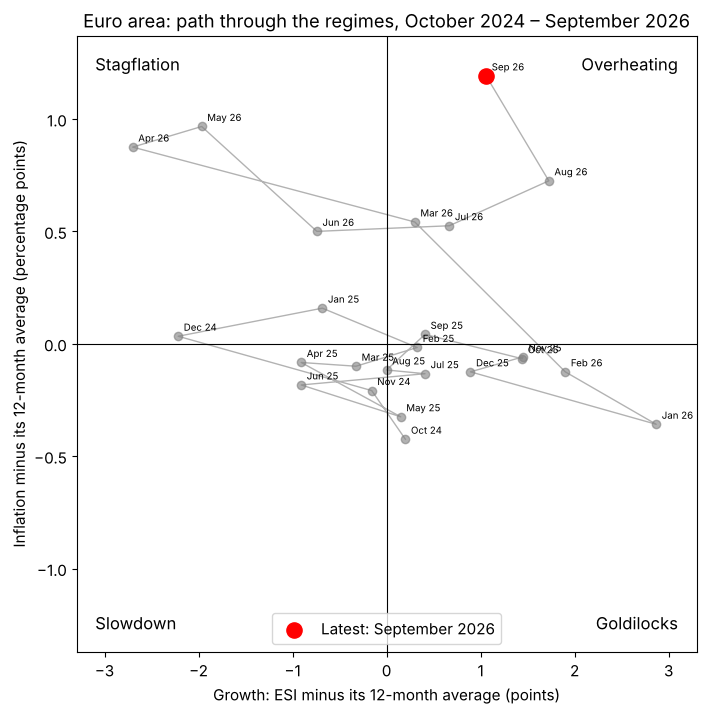

In [6]:
def plot_path(dev, region, growth_label, start="2024-10", filename=None):
    recent = dev.loc[start:]
    x_lim = recent["growth"].abs().max() * 1.15
    y_lim = recent["inflation"].abs().max() * 1.15

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(recent["growth"], recent["inflation"], marker="o", color="grey", alpha=0.6, linewidth=1)
    ax.scatter(recent["growth"].iloc[-1], recent["inflation"].iloc[-1], color="red", s=120, zorder=3,
               label=f"Latest: {recent.index[-1]:%B %Y}")

    for date, row in recent.iterrows():
        ax.annotate(f"{date:%b %y}", (row["growth"], row["inflation"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=7)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(-x_lim, x_lim)
    ax.set_ylim(-y_lim, y_lim)

    ax.text(0.97, 0.97, "Overheating", transform=ax.transAxes, ha="right", va="top", fontsize=12)
    ax.text(0.03, 0.97, "Stagflation", transform=ax.transAxes, ha="left", va="top", fontsize=12)
    ax.text(0.97, 0.03, "Goldilocks", transform=ax.transAxes, ha="right", va="bottom", fontsize=12)
    ax.text(0.03, 0.03, "Slowdown", transform=ax.transAxes, ha="left", va="bottom", fontsize=12)

    ax.set_xlabel(growth_label)
    ax.set_ylabel("Inflation minus its 12-month average (percentage points)")
    ax.set_title(f"{region}: path through the regimes, {recent.index[0]:%B %Y} – {recent.index[-1]:%B %Y}")
    ax.legend(loc="lower center")
    if filename:
        plt.savefig(f"../figures/{filename}", dpi=200, bbox_inches="tight")
    plt.show()

plot_path(dev_ea, "Euro area", "Growth: ESI minus its 12-month average (points)", filename="fig6_ea_quadrant.png")

**Result.** Through 2025 the Euro area stayed close to the centre of the chart: growth and inflation hovered around their 12-month averages, so the regime switched often on small moves (the whipsaw seen in the backtest from 2023). In spring 2026 inflation rose clearly above its average while sentiment fell, moving the economy into Stagflation (April–June). From July sentiment recovered, and by September the Euro area was firmly in Overheating, with inflation 1.2 points above its 12-month average, the largest deviation of the last two years. Unlike in 2025, the current signal is clear rather than borderline.

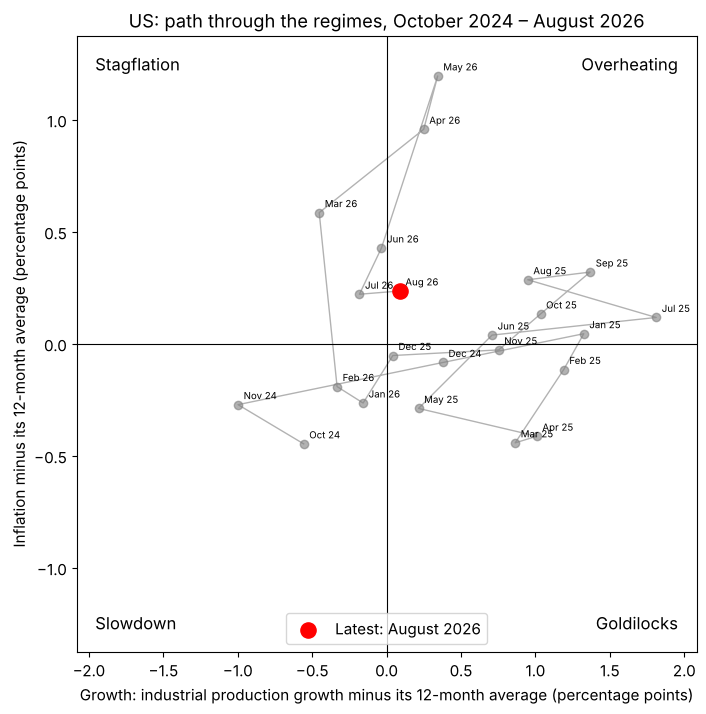

In [7]:
dev_us = deviations(inputs["us_growth"], inputs["us_inflation"])
plot_path(dev_us, "US", "Growth: industrial production growth minus its 12-month average (percentage points)")

**Result.** The US path has crossed three quadrants in 2026: Slowdown in January–February, Stagflation and Overheating during the spring inflation rise, back to the edge of Stagflation in June–July, and only just into Overheating in August (growth +0.09, inflation +0.24 points above their 12-month averages). Both regions are labelled Overheating, but with very different conviction: the Euro area signal is clear, while the US signal is borderline and could flip on small data changes, the same pattern that caused whipsaw in Europe in 2025. The euro-investor portfolio follows the Euro area signal.

## 4. Conclusions

- **Today's signal.** On 3 October 2026 the latest complete data is September for the Euro area (the ESI is published at the end of the month and the flash HICP on the first working day after) and August for the US (CPI and industrial production are published mid-month). After the same publication lags as the backtest (1 and 2 months), both set the October portfolio, and both point to **Overheating**.
- **Implied portfolio.** The euro-investor strategy follows the Euro area signal: 20 points move out of interest-rate-sensitive bonds (long Treasuries −10, investment-grade credit −10, to zero) into commodities (+10) and equities (+5 each for US and European). Cash and gold stay at their neutral weights.
- **Conviction.** The Euro area signal is clear (sentiment +1.1 and inflation +1.2 above their 12-month averages); the US signal is borderline (+0.1 and +0.2) and could flip on small data changes, so the agreement between the two labels adds little confidence. More importantly, the backtest found the regime edge to be small and not statistically significant, so the October tilt should be read as a modest adjustment to a diversified portfolio, not a strong market call.